# L5d Lab: Minimum-Cost Assignment as a Flow LP

> **Learning objectives**
>
> - Convert node conservation into an incidence-matrix equation $A f=b$.
> - Minimize assignment cost subject to a required flow and edge capacities.
> - Extract worker–task decisions from edge-flow variables.
> - Validate bounds, conservation residuals, and the recomputed objective.
> - Re-optimize after an assignment becomes unavailable.


## Setup and corrected teaching data

The Fall 2025 graph structure is retained. Fall 2026 uses differentiated synthetic worker–task costs so the minimum-cost decision is meaningful and reproducible.


In [1]:
include(joinpath(@__DIR__, "Include.jl"))


In [2]:
node_coordinates = [
    10.0 10.0;
    11.0 11.0; 11.0 10.0; 11.0 9.0;
    12.0 11.0; 12.0 10.0; 12.0 9.0; 12.0 8.0;
    13.0 11.0; 13.0 10.0; 13.0 9.0; 13.0 8.0;
    14.0 10.0;
]


13×2 Matrix{Float64}:
 10.0  10.0
 11.0  11.0
 11.0  10.0
 11.0   9.0
 12.0  11.0
 12.0  10.0
 12.0   9.0
 12.0   8.0
 13.0  11.0
 13.0  10.0
 13.0   9.0
 13.0   8.0
 14.0  10.0

In [3]:
edge_path = joinpath(CHEME5800_L5D_DATA, "Workers-Tasks-MCMF-Bipartite.edgelist")
edges = read_flow_edges(edge_path)


23-element Vector{FlowEdge}:
 FlowEdge(1, 2, 0.0, 0.0, 1.0)
 FlowEdge(1, 3, 0.0, 0.0, 1.0)
 FlowEdge(1, 4, 0.0, 0.0, 1.0)
 FlowEdge(5, 9, 1.0, 0.0, 1.0)
 FlowEdge(6, 10, 1.0, 0.0, 1.0)
 FlowEdge(7, 11, 1.0, 0.0, 1.0)
 FlowEdge(8, 12, 1.0, 0.0, 1.0)
 FlowEdge(9, 13, 0.0, 0.0, 1.0)
 FlowEdge(10, 13, 0.0, 0.0, 1.0)
 FlowEdge(11, 13, 0.0, 0.0, 1.0)
 FlowEdge(12, 13, 0.0, 0.0, 1.0)
 FlowEdge(2, 5, 1.0, 0.0, 1.0)
 FlowEdge(2, 6, 4.0, 0.0, 1.0)
 FlowEdge(2, 7, 6.0, 0.0, 1.0)
 FlowEdge(2, 8, 3.0, 0.0, 1.0)
 FlowEdge(3, 5, 5.0, 0.0, 1.0)
 FlowEdge(3, 6, 1.0, 0.0, 1.0)
 FlowEdge(3, 7, 4.0, 0.0, 1.0)
 FlowEdge(3, 8, 2.0, 0.0, 1.0)
 FlowEdge(4, 5, 4.0, 0.0, 1.0)
 FlowEdge(4, 6, 3.0, 0.0, 1.0)
 FlowEdge(4, 7, 1.0, 0.0, 1.0)
 FlowEdge(4, 8, 5.0, 0.0, 1.0)

## Task 1: Assemble the linear program

Each edge is one variable. With inflow recorded as $+1$ and outflow as $-1$, the incidence formulation is

$$\min_f c^Tf\quad\text{s.t.}\quad Af=b,\qquad \ell\le f\le u.$$

For a required flow $F=3$, $b_s=-3$, $b_t=3$, and every intermediate entry is zero.


In [4]:
required_flow = 3.0
form = flow_formulation(edges, 1, 13, required_flow)
(nodes = length(form.vertices), edges = length(edges),
 matrix_size = size(form.A), source_balance = form.b[1], sink_balance = form.b[end])


(nodes = 13, edges = 23, matrix_size = (13, 23), source_balance = -3.0, sink_balance = 3.0)

In [5]:
@test all(sum(form.A; dims = 1) .== 0.0)
@test sum(form.b) == 0.0
:incidence_invariants_verified


:incidence_invariants_verified

## Task 2: Solve, extract assignments, and validate


In [6]:
result = solve_min_cost_flow(edges, 1, 13, required_flow)
validation = validate_flow_solution(edges, result)
assignments = selected_assignments(result)

assignment_table = DataFrame(assignments)
pretty_table(assignment_table)
(minimum_cost = result.cost, valid = validation.valid,
 maximum_balance_residual = maximum(abs, result.residual))


┌────────┬───────┬─────────┐
│ worker │  task │    flow │
│  Int64 │ Int64 │ Float64 │
├────────┼───────┼─────────┤
│      2 │     5 │     1.0 │
│      3 │     6 │     1.0 │
│      4 │     7 │     1.0 │
└────────┴───────┴─────────┘


(minimum_cost = 6.0, valid = true, maximum_balance_residual = 0.0)

In [7]:
@test validation.valid
@test result.cost == 6.0
@test [(item.worker, item.task) for item in assignments] == [(2, 5), (3, 6), (4, 7)]
:minimum_cost_assignment_verified


:minimum_cost_assignment_verified

In [8]:
function plot_cost_flow(edges, result, coordinates; title = "Minimum-cost assignment flow")
    figure = plot(; axis = nothing, border = :none, legend = false, title = title,
        xlim = (9.5, 14.5), ylim = (7.5, 11.5), size = (850, 450))
    for edge in edges
        key = (edge.source, edge.target)
        value = result.flow[key]
        color, width = value > 1e-8 ? (:crimson, 3) : (:gray85, 1.2)
        plot!([coordinates[edge.source, 1], coordinates[edge.target, 1]],
              [coordinates[edge.source, 2], coordinates[edge.target, 2]];
              arrow = true, color = color, lw = width, label = "")
        if edge.source in 2:4 && edge.target in 5:8
            mx = (coordinates[edge.source, 1] + coordinates[edge.target, 1]) / 2
            my = (coordinates[edge.source, 2] + coordinates[edge.target, 2]) / 2
            annotate!(mx, my + 0.12, text("c=$(Int(edge.cost))", 7, color))
        end
    end
    scatter!(coordinates[:, 1], coordinates[:, 2]; c = :slategray, ms = 13, label = "")
    scatter!([coordinates[1, 1], coordinates[13, 1]], [coordinates[1, 2], coordinates[13, 2]];
        c = [:seagreen, :firebrick], ms = 15, label = "")
    for vertex in axes(coordinates, 1)
        annotate!(coordinates[vertex, 1], coordinates[vertex, 2], text(string(vertex), 8, :white))
    end
    return figure
end


plot_cost_flow (generic function with 1 method)

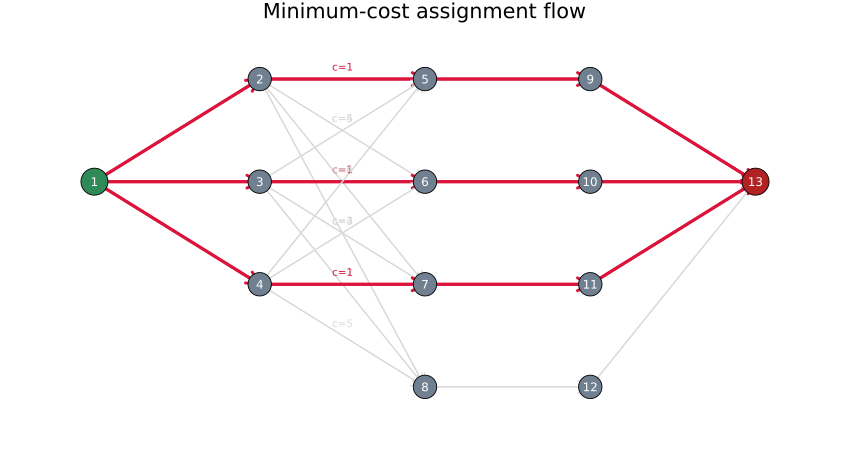

In [9]:
plot_cost_flow(edges, result, node_coordinates)


The objective includes one unit of task-completion cost for each selected task. Thus the three preferred worker–task edges cost 3 in total and the completion edges add 3, giving an objective of 6.


## Task 3: Sensitivity—worker 4 can no longer perform task 7


In [10]:
disrupted_edges = [
    edge.source == 4 && edge.target == 7 ?
        FlowEdge(edge.source, edge.target, edge.cost, 0.0, 0.0) : edge
    for edge in edges
]
disrupted_result = solve_min_cost_flow(disrupted_edges, 1, 13, required_flow)
disrupted_assignments = selected_assignments(disrupted_result)
pretty_table(DataFrame(disrupted_assignments))
(new_cost = disrupted_result.cost, cost_increase = disrupted_result.cost - result.cost)


┌────────┬───────┬─────────┐
│ worker │  task │    flow │
│  Int64 │ Int64 │ Float64 │
├────────┼───────┼─────────┤
│      2 │     5 │     1.0 │
│      3 │     8 │     1.0 │
│      4 │     6 │     1.0 │
└────────┴───────┴─────────┘


(new_cost = 9.0, cost_increase = 3.0)

In [11]:
@test validate_flow_solution(disrupted_edges, disrupted_result).valid
@test disrupted_result.cost > result.cost
:disrupted_network_verified


:disrupted_network_verified

## Summary

- The incidence matrix makes flow conservation a linear equality.
- Bounds encode edge availability and capacity; costs rank feasible assignments.
- The optimal assignment is a consequence of the whole network, not three independent cheapest-edge choices.
- When an edge becomes unavailable, re-solve and re-validate—the old solution is no longer feasible.
